# RNA seq related plots in the paper
@Siqi Du

# Plot bulk RNA seq dataset

Cell line: ESI017

Condition: during neural differentiation (N2B27, SB, LDN), WNT3A is added at 34h, samples are collected at timepoints 34h, 42h, 50h, 72h

In [1]:
# reload .csv file of the combined
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
from pathlib import Path
base_dir = Path("/Users/dududu/Library/CloudStorage/Box-Box/Siqi/bulkRNAseq")
data = pd.read_csv(base_dir / "AP_neural_Wnt_FGF/data/abundance_combined_W.csv")
data.drop(data.columns[0], axis=1, inplace=True)
print(data)

            Ensembl ID   Gene name      H34_1      H34_2    W_H42_1  \
0      ENSG00000000003      TSPAN6  68.645747  75.537798  70.819633   
1      ENSG00000000005        TNMD   1.197405   0.403021   0.201286   
2      ENSG00000000419        DPM1  72.284205  79.267739  79.507586   
3      ENSG00000000457       SCYL3   3.313200   4.147827   3.223417   
4      ENSG00000000460    C1orf112  19.929445  20.447366  22.909201   
...                ...         ...        ...        ...        ...   
37946  ENSG00000287988  FO082814.1   0.000000   0.000000   0.000000   
37947  ENSG00000288000  AL031681.2   0.000000   0.000000   0.000000   
37948  ENSG00000288014  AL121969.1   0.000000   0.000000   0.000000   
37949  ENSG00000288031  AC093838.2   0.237767   0.099430   0.198646   
37950  ENSG00000288053  AC231657.3   0.000000   0.000000   0.000000   

         W_H42_2    W_H50_1    W_H50_2    W_H72_1    W_H72_2  
0      71.804691  60.287818  72.290161  72.149337  69.384674  
1       1.325532   0.

In [5]:
def get_value(data_exp, gene_name, trt):
    gene_idx = data_exp.index[data["Gene name"] == gene_name].tolist()
    return np.array(data_exp.iloc[gene_idx][trt])[0]

def get_gene_exp_mat(data_exp, gene_name, trt='W', time_points=[34,42,50,72]):
    repl_data = []
    for tp in time_points:
        if tp == 34:
            repl_data.append({'Time': tp,
                              'R1': get_value(data_exp, gene_name, f"H{tp}_1"),
                              'R2': get_value(data_exp, gene_name, f"H{tp}_2")})  
        else:
            repl_data.append({'Time': tp,
                              'R1': get_value(data_exp, gene_name, f"W_H{tp}_1"),
                              'R2': get_value(data_exp, gene_name, f"W_H{tp}_2")})
    repl_data = pd.DataFrame(repl_data)
    return repl_data

def plot_genes(data_exp, gene_names, colors=sns.color_palette("muted")):
    
    fig, ax = plt.subplots(figsize=(5,4.5))
    ax.set_xlabel("Time (h)", fontsize=16)
    ax.set_ylabel("Expression (TPM)", fontsize=16)

    time_points=[34,42,50,72]
    for idx,gene in enumerate(gene_names):
        repl_data = get_gene_exp_mat(data, gene_names[idx])
        array_mean = repl_data[["R1","R2"]].mean(axis=1).to_numpy()
        array_se = repl_data[["R1","R2"]].std(axis=1).to_numpy()/math.sqrt(2)
        plt.errorbar(time_points, array_mean, yerr=array_se, color=colors[idx], linewidth=2.5)
    
    font_props = fm.FontProperties(style='italic', size=16)
    plt.legend(gene_names, prop=font_props)
    fig.savefig(base_dir / f"APmicropatterns/LinePlot-{'-'.join(gene_names)}.png", dpi=300)

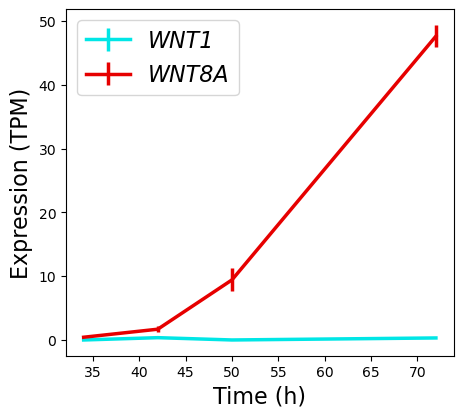

In [7]:
# WNT1 and WNT8A
gene_names = ["WNT1","WNT8A"]
plot_genes(data, gene_names, colors=[[0,0.9,0.9],[0.9,0,0]])

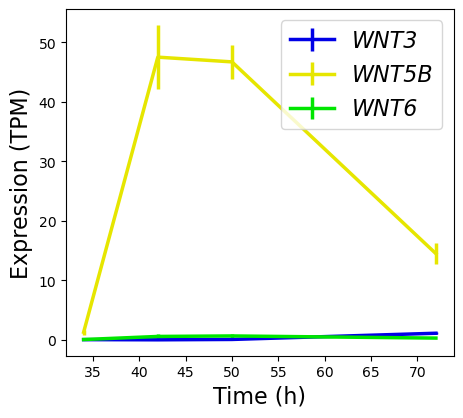

In [8]:
# Other Wnt ligands
gene_names = ["WNT3","WNT5B","WNT6"]
plot_genes(data, gene_names, colors=[[0,0,0.9],[0.9,0.9,0],[0,0.9,0]])

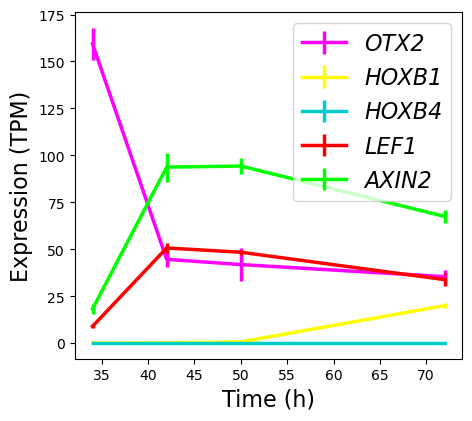

In [11]:
# Cell fate and signaling markers
gene_names = ["OTX2","HOXB1","HOXB4","LEF1","AXIN2"]
plot_genes(data, gene_names, colors=[[1,0,1],[1,1,0],[0,0.8,0.8],[1,0,0],[0,1,0]])